### What are the proportions of dem and rep in the senate among presidential swing states?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sen_cand = pd.read_csv("data/senate_county_candidate.csv")

display(sen_cand)

,state,county,candidate,party,total_votes
0,Delaware,Kent County,Lauren Witzke,REP,38571
1,Delaware,Kent County,Mark Turley,IPD,1553
2,Delaware,Kent County,Nadine Frost,LIB,958
3,Delaware,New Castle County,Lauren Witzke,REP,80081
4,Delaware,New Castle County,Mark Turley,IPD,4277
...,...,...,...,...,...
14120,Georgia,Worth County,Ed Tarver,DEM,17
14121,Georgia,Worth County,John Fortuin,GRN,15
14122,Georgia,Worth County,Valencia Stovall,IND,15
14123,Georgia,Worth County,Michael Greene,IND,14


In [11]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in sen_cand.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
df_proportions_senate = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner})

display(df_proportions_senate)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner
0,Alabama,0.745786,0.249344,0.004869,DEM
1,Alaska,0.590108,0.294475,0.115417,DEM
2,Arizona,0.173511,0.825695,0.000795,REP
3,Arkansas,0.000000,0.228876,0.771124,IND
4,Colorado,0.350723,0.589283,0.059994,REP
5,Delaware,0.298814,0.631578,0.069608,REP
6,Georgia,0.405144,0.544882,0.049975,REP
7,Idaho,0.834971,0.052484,0.112545,DEM
8,Illinois,0.210579,0.625000,0.164421,REP
9,Iowa,0.513389,0.414488,0.072122,DEM


In [4]:
sen_cand_grouped = sen_cand.groupby( ["state", "party"] ).agg(state_vote = ('total_votes', 'sum'))
sen_cand_grouped = sen_cand_grouped.reset_index()
party = sen_cand_grouped.pivot(index=["state"], columns=["party"], values="state_vote")
cols = party.columns[(party.columns != "DEM") & (party.columns != "REP")]
party["Independent"] = party[cols].sum(axis=1)
party["Total"] = party[["DEM", "REP", "Independent"]].sum(axis=1)
party["Dem Proportion"] = party["DEM"] / party["Total"]
party["Rep Proportion"] = party["REP"] / party["Total"]
party["Ind Proportion"] = party["Independent"] / party["Total"]
party[["Dem Proportion", "Rep Proportion", "Ind Proportion"]]

sen_party = party[["Dem Proportion", "Rep Proportion", "Ind Proportion"]]
sen_party

party,Dem Proportion,Rep Proportion,Ind Proportion
state,,,
Alabama,0.745786,0.249344,0.004869
Alaska,0.590108,0.294475,0.115417
Arizona,0.173511,0.825695,0.000795
Arkansas,NaN,0.228876,0.771124
Colorado,0.350723,0.589283,0.059994
Delaware,0.298814,0.631578,0.069608
Georgia,0.405144,0.544882,0.049975
Idaho,0.834971,0.052484,0.112545
Illinois,0.210579,0.625000,0.164421


In [5]:
df = pd.read_csv("data/president_county_candidate.csv")

states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in df.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
df_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner})

display(df_proportions)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner
0,Alabama,0.365707,0.620310,0.013984,REP
1,Alaska,0.391993,0.485228,0.122779,REP
2,Arizona,0.493647,0.490560,0.015793,DEM
3,Arkansas,0.347751,0.623957,0.028292,REP
4,California,0.634992,0.343278,0.021730,DEM
5,Colorado,0.554000,0.418983,0.027017,DEM
6,Connecticut,0.592387,0.392095,0.015518,DEM
7,Delaware,0.587822,0.398014,0.014164,DEM
8,District of Columbia,0.921497,0.053973,0.024530,DEM
9,Florida,0.478615,0.512198,0.009187,REP


In [6]:
# pres_prop is the cleaned dataframe with proportion democrat & proportion republican

df_proportions["margin"] = df_proportions["Proportion_Democrat"] - df_proportions["Proportion_Republican"]
df_proportions["margin_abs"] = abs(df_proportions["margin"])
swing = df_proportions.query("margin_abs <= 0.05")
swing

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner,margin,margin_abs
2,Arizona,0.493647,0.490560,0.015793,DEM,0.003087,0.003087
9,Florida,0.478615,0.512198,0.009187,REP,-0.033584,0.033584
10,Georgia,0.494953,0.492596,0.012451,DEM,0.002357,0.002357
22,Michigan,0.506208,0.478373,0.015419,DEM,0.027835,0.027835
28,Nevada,0.500568,0.476662,0.022770,DEM,0.023905,0.023905
33,North Carolina,0.485862,0.499343,0.014794,REP,-0.013481,0.013481
38,Pennsylvania,0.499609,0.487818,0.012573,DEM,0.011792,0.011792
49,Wisconsin,0.494540,0.488290,0.017170,DEM,0.006250,0.006250


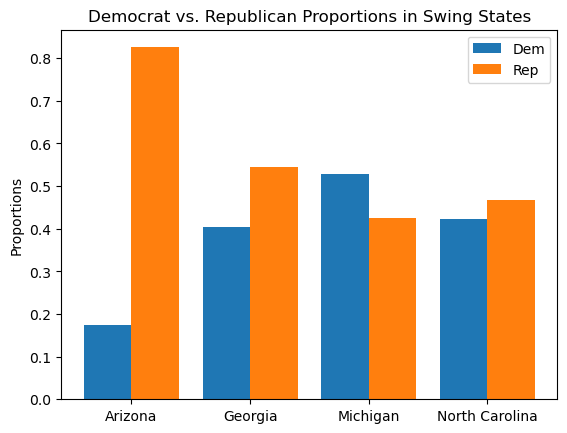

party,Dem Proportion,Rep Proportion,Ind Proportion
state,,,
Arizona,0.173511,0.825695,0.000795
Georgia,0.405144,0.544882,0.049975
Michigan,0.529049,0.425138,0.045813
North Carolina,0.423432,0.466471,0.110097


In [7]:
cats = swing["State"].tolist()

senate = sen_party.query("state in @cats") # took the senate proportions of states that are presidential swings

senate_states = senate.reset_index() # made state a column instead of an index

senate_states_list = senate_states["state"].tolist() # created a list of states that have senate proportions of presidential swings

v1, v2 = senate["Dem Proportion"], senate["Rep Proportion"]
w, x = 0.4, np.arange(len(senate_states_list))

plt.bar(x - w/2, v1, w, label='Dem')
plt.bar(x + w/2, v2, w, label='Rep')

plt.xticks(x, senate_states_list)
plt.ylabel('Proportions')
plt.title('Democrat vs. Republican Proportions in Swing States')
plt.legend()
plt.show()
display(senate)

In [8]:
sen_party2 = sen_party.reset_index()

In [9]:
sen_party2.to_csv("data/senate_proportions.csv", index = False)

In [ ]:
display(sen_party2)

party,state,Dem Proportion,Rep Proportion,Ind Proportion
0,Alabama,0.745786,0.249344,0.004869
1,Alaska,0.590108,0.294475,0.115417
2,Arizona,0.173511,0.825695,0.000795
3,Arkansas,NaN,0.228876,0.771124
4,Colorado,0.350723,0.589283,0.059994
5,Delaware,0.298814,0.631578,0.069608
6,Georgia,0.405144,0.544882,0.049975
7,Idaho,0.834971,0.052484,0.112545
8,Illinois,0.210579,0.625000,0.164421
9,Iowa,0.513389,0.414488,0.072122
